In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv("~/Desktop/Research/Datasets/Snf2_raw.tsv",sep="\t",index_col=0,header=None)
df2 = pd.read_csv("~/Desktop/Research/Datasets/WT_raw.tsv",sep="\t",index_col=0,header=None)
outpath = "/Users/jolivie1/Desktop/Research/equivalence_testing/notebooks/output/Snf2_filtering/"
dfs = [df1, df2]

names = ["Snf2", "WT"]


In [3]:
df2

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
0,,,,,,,,,,,,,,,,,,,,,
15s_rrna,2,12,31,8,21,11,2,3,7,6,...,0,49,9,4,11,12,1,22,12,4
21s_rrna,20,76,101,99,128,74,36,32,57,104,...,10,274,49,30,72,58,21,159,107,70
hra1,3,2,2,2,3,5,4,0,4,4,...,5,3,6,5,2,2,2,5,2,1
icr1,75,123,107,157,98,245,119,120,119,132,...,85,177,137,118,113,81,142,94,187,106
lsr1,60,163,233,163,193,375,194,84,211,158,...,66,385,232,149,114,81,109,132,243,128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ty(gua)j2,0,1,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ty(gua)m1,0,0,1,1,1,1,0,0,1,0,...,0,1,1,0,1,0,0,0,1,0
ty(gua)m2,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


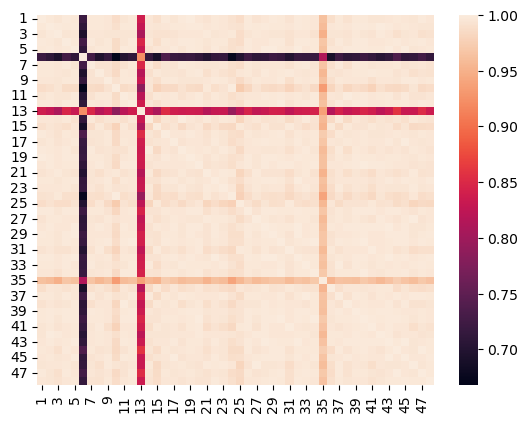

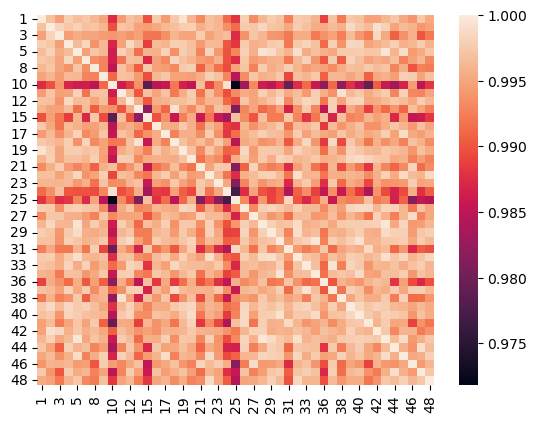

(7126, 45)


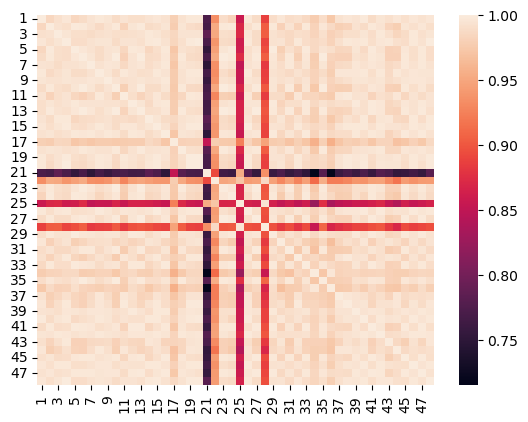

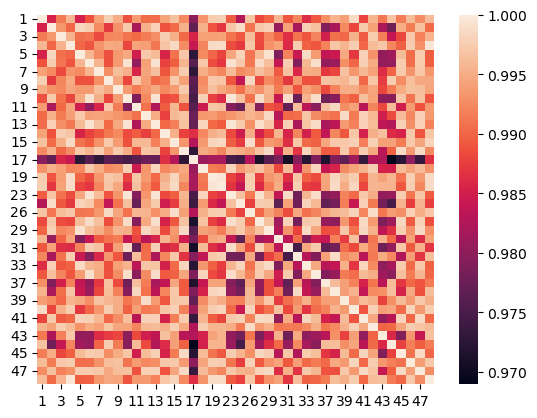

(7126, 42)


In [4]:
filtered_dfs = []
for df in [df1,df2]:
    corr = df.corr()
    sns.heatmap(corr)
    plt.show()

    mean = corr.mean()
    filtered_df = df.loc[:,mean[mean > 0.97].index]
    filtered_corr = filtered_df.corr()
    
    sns.heatmap(filtered_corr)
    plt.show()
    filtered_dfs.append(filtered_df)
    print(filtered_df.shape)

In [9]:
filtered_df.shape

(7126, 42)

In [10]:
df.shape

(7126, 48)

In [14]:
num_replicates = 30
for i in range(len(dfs)):
    
    
    df_random = filtered_dfs[i].sample(n=2*num_replicates, axis=1, random_state=42, replace=False)
    
    samples = [f'A{x}' for x in range(1,num_replicates + 1)] + [f"B{x}" for x in range(1,num_replicates + 1)]
    df_random.columns = samples
    df_random.to_csv(f"{outpath}{names[i]}_{num_replicates}.csv")
    meta = pd.DataFrame({"sample" : samples, "condition" : ["A"] * num_replicates + ["B"] * num_replicates})
    meta.to_csv(f"{outpath}meta_{names[i]}_{num_replicates}.csv", index = False)

ValueError: Cannot take a larger sample than population when 'replace=False'

In [23]:
num_replicates = 6
df_random1 = filtered_dfs[0].sample(n=num_replicates, axis=1, random_state=42, replace=False)
df_random2 = filtered_dfs[1].sample(n=num_replicates, axis=1, random_state=42, replace=False)
df_random = pd.concat((df_random1, df_random2),axis=1)
samples = [f'{names[0]}_{x}' for x in range(1,num_replicates + 1)] + [f"{names[1]}_{x}" for x in range(1,num_replicates + 1)]
df_random.columns = samples
df_random.to_csv(f"{outpath}{names[0]}_{names[1]}_{num_replicates}.csv")

meta = pd.DataFrame({"sample" : samples, "condition" : [names[0]] * num_replicates + [names[1]] * num_replicates})
meta.to_csv(f"{outpath}meta_{names[0]}_{names[1]}_{num_replicates}.csv", index = False)

In [25]:
df_random

,Snf2_1,Snf2_2,Snf2_3,Snf2_4,Snf2_5,Snf2_6,WT_1,WT_2,WT_3,WT_4,WT_5,WT_6
0,,,,,,,,,,,,
15s_rrna,85,13,6,6,7,34,13,12,7,4,21,22
21s_rrna,576,192,60,44,64,234,61,75,57,34,128,159
hra1,0,0,1,0,5,2,3,4,4,7,3,5
icr1,202,151,216,195,286,148,186,156,119,133,98,94
lsr1,742,199,134,224,250,227,177,131,211,265,193,132
...,...,...,...,...,...,...,...,...,...,...,...,...
ty(gua)j2,0,0,1,1,1,0,0,0,0,0,0,0
ty(gua)m1,0,0,0,0,1,0,0,0,1,1,1,0
ty(gua)m2,0,0,0,0,0,0,0,0,0,1,0,0


In [27]:
meta

,sample,condition
0,Snf2_1,Snf2
1,Snf2_2,Snf2
2,Snf2_3,Snf2
3,Snf2_4,Snf2
4,Snf2_5,Snf2
5,Snf2_6,Snf2
6,WT_1,WT
7,WT_2,WT
8,WT_3,WT
9,WT_4,WT
